In [38]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:
import os
import matplotlib.pyplot as plt

In [40]:
from eyewire2_functional_analysis import data_loader

data_folder = "../../../data/preprocessed-data"
morph_folder = "../../../data/morphological-data"

In [41]:
print(sorted(os.listdir(morph_folder)))

['Eyewire II Proofread Cells Main List - All Cells 2026-05-09b-resource-paper-v2.csv', 'Eyewire II Proofread Cells Master List - All Cells 2026-03-17.csv', 'roi_mapping_2p_to_em.csv', 'v2026-05-15-15h']


In [42]:
df_rois, df_fields, df_outline = data_loader.load_all_dfs(data_folder)

df = data_loader.load_df_rois_morph(
    morph_folder=morph_folder,
    morph_spreadsheet_filename='Eyewire II Proofread Cells Main List - All Cells 2026-05-09b-resource-paper-v2.csv',
    nuc_col_master='Latest NucID',
    seg_col_master=(
        'Latest SegID',
        'Proofread SegID'),
    df_rois=df_rois,
)

In [43]:
from eyewire2_functional_analysis import baden16_utils

In [44]:
def infer_cellinfo_using_cellclass(cellclass, probs_per_cluster):
    cluster_is_ac = baden16_utils.BADEN_CLUSTER_INFO[:, -1] == 'dAC'

    probs_per_cluster = probs_per_cluster.copy()
    if cellclass == 'AC':
        probs_per_cluster[~cluster_is_ac] = 0
    elif cellclass == 'RGC':
        probs_per_cluster[cluster_is_ac] = 0
    else:
        raise ValueError('cellclass must be AC or RGC')

    probs_per_cluster /= probs_per_cluster.sum()
    cluster_id, group_id, supergroup, prob_cluster, prob_group, prob_supergroup, prob_class = (
        baden16_utils.baden16_cluster_probs_to_info(probs_per_cluster))

    return cluster_id, group_id, supergroup, prob_cluster, prob_group, prob_supergroup, prob_class

In [45]:
df['group_id_w_cellclass'] = df.apply(
    lambda row: infer_cellinfo_using_cellclass(row['Cell Class'], row['probs_per_cluster'])[1], axis=1)
df['supergroup_w_cellclass'] = df.apply(
    lambda row: infer_cellinfo_using_cellclass(row['Cell Class'], row['probs_per_cluster'])[2], axis=1)

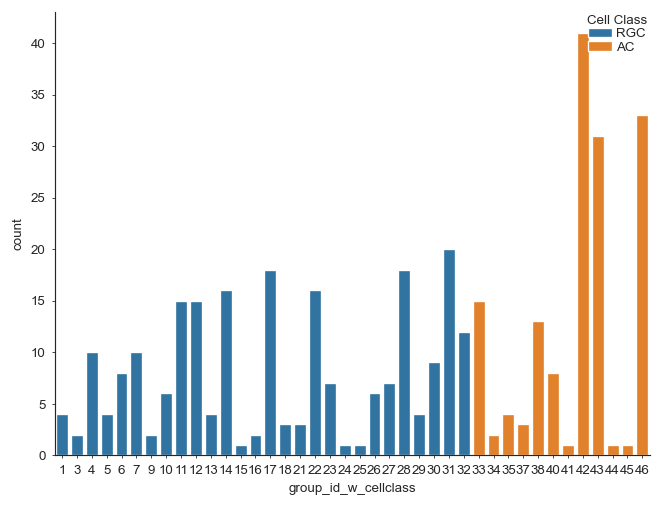

In [46]:
import seaborn as sns

sns.countplot(df, x='group_id_w_cellclass', hue='Cell Class')
plt.show()

In [47]:
from scipy import ndimage
import numpy as np

def downsample_uniform_filter(data, n):
    """Downsample using uniform filter - works with any array size"""
    filtered = ndimage.uniform_filter1d(data, size=n, axis=1)
    return filtered[:, ::n]

# Plot

In [48]:
from eyewire2_functional_analysis.style import set_rc_params

set_rc_params(notebook_dpi=None)

In [49]:
def sg_to_int(sg):
    if sg == 'OFF':
        return 0
    elif sg == 'ON-OFF':
        return 1
    elif sg == 'Fast ON':
        return 2
    elif sg == 'Slow ON':
        return 3
    elif sg == 'Unc. ON':
        return 4
    elif sg == 'Unc. SbC':
        return 5
    elif sg == 'dAC':
        return 6

def int_to_sg(i):
    if i == 0:
        return 'OFF'
    elif i == 1:
        return 'ON-OFF'
    elif i == 2:
        return 'Fast ON'
    elif i == 3:
        return 'Slow ON'
    elif i == 4:
        return 'Unc. ON'
    elif i == 5:
        return 'Unc. SbC'
    elif i == 6:
        return 'dAC'

supergroups = df.supergroup_w_cellclass.values
supergroups_int = np.array([sg_to_int(sg) for sg in supergroups])

In [50]:
sidx = np.argsort(df.group_id_w_cellclass.values)[::-1]

In [51]:
import h5py

try:
    with h5py.File("X:/Resources/Stimulus/chirp.h5", "r") as f:
        chirp_stimulus = f['stimulusarray'][:].T.astype(int)
    chirp_stimulus = np.append(chirp_stimulus, np.full(1000, chirp_stimulus[-1]))
except:
    chirp_stimulus = np.ones(32988).astype(int)

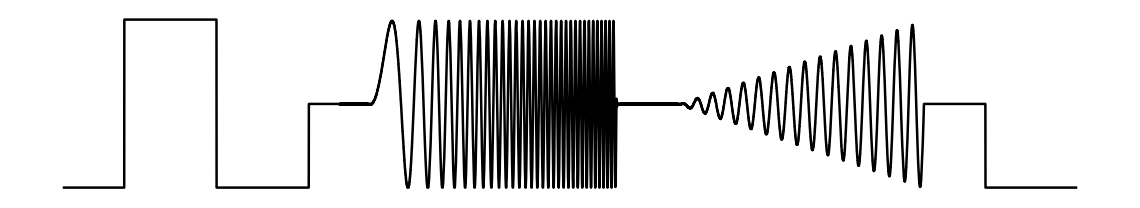

In [52]:
fig, ax = plt.subplots(1, 1, figsize=(12, 2))

ax.axis('off')
ax.plot(np.arange(len(chirp_stimulus))*1e-3, chirp_stimulus, c='k', clip_on=False, lw=1.5, solid_capstyle='butt')
plt.savefig('figures/chirp_stimulus.eps', bbox_inches='tight')

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

supergroups_u_int = np.arange(7)
sg_cmap = ListedColormap([
    "darkred",  # for 0
    "orange",  # for 1
    "green",  # for 2
    "darkblue",  # for 3
    "royalblue",  # for 4
    "purple",  # for 5
    "gray"   # for 6
])
bounds = np.arange(-0.5+supergroups_u_int[0], supergroups_u_int[-1]+0.6, 1)
sg_norm = BoundaryNorm(bounds, sg_cmap.N)

In [54]:
chirps = np.vstack(df['chirp_average_norm'])
bars = np.vstack(df['bar_time_component'])

In [55]:
f_ds = 10
im_sgs = supergroups_int[sidx, np.newaxis].astype(float)
im_chirp = downsample_uniform_filter(data=chirps[sidx], n=f_ds)
im_bar = bars[sidx]

sg_change_idx = np.where(np.diff(im_sgs[:, 0]) != 0)[0] + 1
for i in range(3):
    sg_change_idx = np.append(sg_change_idx[0], sg_change_idx)
sg_change_idx = np.repeat(sg_change_idx, 3)

def insert_nan_rows(image, row_indices):
    """Insert rows of NaNs at specified indices in a 2D numpy array."""
    nan_row = np.full((1, image.shape[1]), np.nan)
    return np.insert(image, row_indices, nan_row, axis=0)

im_sgs = insert_nan_rows(im_sgs, sg_change_idx)
im_chirp = insert_nan_rows(im_chirp, sg_change_idx)
im_bar = insert_nan_rows(im_bar, sg_change_idx)

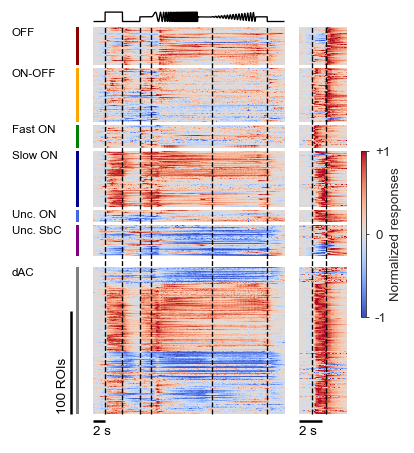

In [ ]:
cmap = 'coolwarm'#'PRGn'

chirp_col = 1
bar_col = 2 if chirp_col == 1 else 1
width_ratios = (0.5, 3, 12, 0.3) if chirp_col == 2 else (0.5, 12, 3, 0.3)

fig, axs = plt.subplots(2, 4, figsize=(3, 4), width_ratios=width_ratios, height_ratios=(1, 40), sharex='col')
sns.despine(left=True, bottom=True)


ax = axs[1, 0]
ax.axis('off')
im = ax.imshow(im_sgs, aspect='auto',
               cmap=sg_cmap, norm=sg_norm,
               interpolation='none', extent=(0, 1, 0, 1), origin='lower')
ax.plot([0, 1], [-.02, -.02], c=(1, 1, 1, 0), solid_capstyle='butt', lw=1.5)
ax.text(0, -0.03, ' ', c=(1, 1, 1, 0), ha='left', rotation=0, va='top', fontsize=8)

ax = axs[0, chirp_col]
ax.axis('off')
ax.plot(np.arange(len(chirp_stimulus))*1e-3, chirp_stimulus, c='k', clip_on=False, lw=0.8, solid_capstyle='butt')

ax = axs[1, chirp_col]
ax.grid(False)
ax.set(xticks=[], yticks=[])
ax.imshow(im_chirp, aspect='auto', vmin=-1, vmax=1, cmap=cmap, interpolation='none', extent=(0, 33, 0, 1), origin='lower')
for t in [2, 5, 8, 10, 20.5, 30]:
    ax.plot([t, t], [0, 1], c='k', lw=0.8, ls='--')
ax.plot([0, 2], [-.02, -.02], c='k', solid_capstyle='butt', lw=1.5)
ax.text(0, -0.03, '2 s', c='k', ha='left', rotation=0, va='top', fontsize=8)

ax = axs[0, bar_col]
ax.axis('off')

ax = axs[0, 0]
ax.axis('off')

ax = axs[0, 3]
ax.axis('off')

ax = axs[1, bar_col]
ax.grid(False)
ax.axis('off')
im = ax.imshow(im_bar, aspect='auto', vmin=-1, vmax=1, cmap=cmap, interpolation='none', extent=(0, 4.224, 0, 1), origin='lower')

for t in [1.152, 2.432]:
    ax.plot([t, t], [0, 1], c='k', lw=0.8, ls='--')
ax.plot([0, 2], [-.02, -.02], c='k', solid_capstyle='butt', lw=1.5)
ax.text(0, -0.03, '2 s', c='k', ha='left', rotation=0, va='top', fontsize=8)

ax = axs[1, 3]
cbar = plt.colorbar(im, ax=ax, cax=ax, orientation='vertical')
cbar.outline.set_linewidth(0.5)
cbar.set_label('Normalized responses', fontsize=8, labelpad=0)
cbar.set_ticks([-1, 0, 1])
cbar.set_ticklabels(["-1", "0", "+1"], fontsize=8)

plt.tight_layout(h_pad=0.05)

ax = axs[1, 0]
ax.set_ylabel('Cells sorted by functional group', fontsize=8)
dscale = 80
ax.plot([-0.02*dscale, -0.02*dscale], [0, 100/len(sidx)], c='k', solid_capstyle='butt', lw=1.5, clip_on=False)
ax.text(-0.03*dscale, 0, f'100 ROIs', c='k', ha='right', rotation=90, va='bottom', fontsize=8)

ax = axs[-1, -1]
pos = ax.get_position()
new_pos = [pos.x0, pos.y0 + pos.height*0.3, pos.width, pos.height*0.4]
ax.set_position(new_pos)

ax = axs[1, 0]
for i, (sg1, sg2) in enumerate(zip(np.append(np.nan, im_sgs[:, 0])[:-1] , im_sgs[:, 0])):
    if np.isnan(sg1) and not np.isnan(sg2):
        sg_name = int_to_sg(int(sg2))
        ax.text(-22, (i + np.sum(im_sgs[:, 0] == sg2)) / im_sgs.shape[0], sg_name, c='k', ha='left', va='top', fontsize=7)

plt.savefig(f'figures/response_overview_{chirp_col}.svg', bbox_inches='tight')